In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utility.utils import data_distribution_frame, model_selection_fig_dir, evaluate_model, plot_pr_curve, cross_val_scores_plot

from sklearn.model_selection import train_test_split, StratifiedKFold, LearningCurveDisplay
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.dummy import DummyClassifier

np.random.seed(37)

In [2]:
data = pd.read_csv('../data/application_train.csv')

In [3]:
target = data['TARGET']
data.drop(columns=['TARGET'], inplace=True)

# Train-Test Split

In [4]:
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.60, shuffle=True, stratify=target, random_state=37)

In [5]:
print(f'data_train = {data_train.shape}')
print(f'target_train = {target_train.shape}')
print(f'data_test = {data_test.shape}')
print(f'target_test = {target_test.shape}')

data_train = (123004, 121)
target_train = (123004,)
data_test = (184507, 121)
target_test = (184507,)


In [6]:
data_distribution_frame(target_train)

,value counts,percent of total
0,113074,92%
1,9930,8%


In [7]:
data_distribution_frame(target_test)

,value counts,percent of total
0,169612,92%
1,14895,8%


# Preprocessing Pipelines

In [8]:
cat_columns = make_column_selector(dtype_include='object')(data_train)
num_columns = make_column_selector(dtype_exclude='object')(data_train)

In [9]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist', min_frequency=1)
)
cat_pipeline

,steps,"[('simpleimputer', ...), ('onehotencoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [10]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'), RobustScaler()
)
num_pipeline

,steps,"[('simpleimputer', ...), ('robustscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


In [11]:
imputation_encoding = ColumnTransformer(transformers=[
    ('nums', num_pipeline, num_columns),
    ('cat_ohe', cat_pipeline, cat_columns),
], remainder='passthrough', n_jobs=-1)
imputation_encoding

,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [12]:
preprocessing = make_pipeline(imputation_encoding, PCA(n_components=24, svd_solver='randomized', random_state=37))
preprocessing

,steps,"[('columntransformer', ...), ('pca', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Algorithms Spot-checking

In [13]:
dummy_clf=make_pipeline(preprocessing, DummyClassifier(strategy='most_frequent', random_state=37))
lr_clf =  make_pipeline(preprocessing, LogisticRegressionCV(scoring='average_precision', n_jobs=-1, random_state=37))
sgd_clf = make_pipeline(preprocessing, SGDClassifier(class_weight='balanced', n_jobs=-1, random_state=37))
mlp_clf = make_pipeline(preprocessing, MLPClassifier(random_state=37))
rdf_clf = make_pipeline(preprocessing, RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=37))
hgb_clf = make_pipeline(preprocessing, HistGradientBoostingClassifier(class_weight='balanced', random_state=37))

## PR-AUC  and F1-Score

In [14]:
dummy_clf_df = pd.DataFrame.from_dict(evaluate_model(dummy_clf, data_train, target_train), orient='columns')
lr_clf_df = pd.DataFrame.from_dict(evaluate_model(lr_clf, data_train, target_train), orient='columns')
sgd_clf_df = pd.DataFrame.from_dict(evaluate_model(sgd_clf, data_train, target_train), orient='columns')
mlp_clf_df = pd.DataFrame.from_dict(evaluate_model(mlp_clf, data_train, target_train), orient='columns')
rdf_clf_df = pd.DataFrame.from_dict(evaluate_model(rdf_clf, data_train, target_train), orient='columns')
hgb_clf_df = pd.DataFrame.from_dict(evaluate_model(hgb_clf, data_train, target_train), orient='columns')

In [15]:
model_scores = [dummy_clf_df, lr_clf_df, sgd_clf_df, mlp_clf_df, rdf_clf_df, hgb_clf_df]
model_names = ['dummy_clf', 'lr_clf', 'sgd_clf', 'mlp_clf', 'rdf_clf', 'hgb_clf']

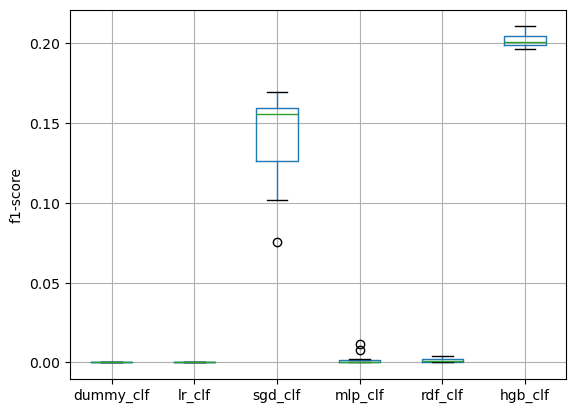

In [16]:
cross_val_scores_plot(model_scores, model_names, choice_column='f1-score')
plt.savefig(f"{model_selection_fig_dir}/cv-f1-scores.png")
plt.show()

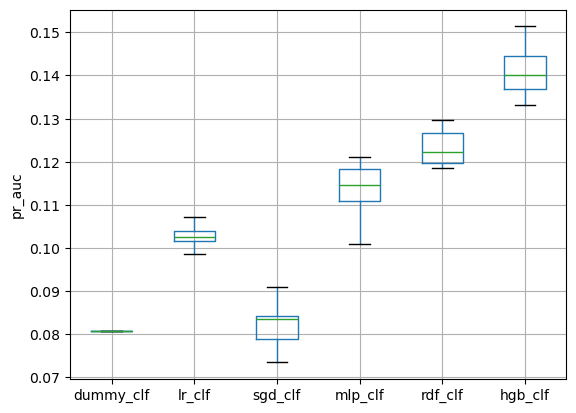

In [17]:
cross_val_scores_plot(model_scores, model_names, choice_column='pr_auc')
plt.savefig(f"{model_selection_fig_dir}/cv-pr-auc-scores.png")
plt.show()

## Effect  of Training size

In [18]:
preprocessed_data = preprocessing.fit_transform(data_train)

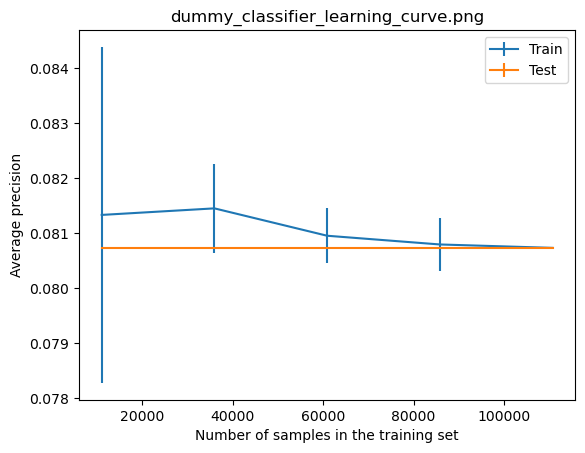

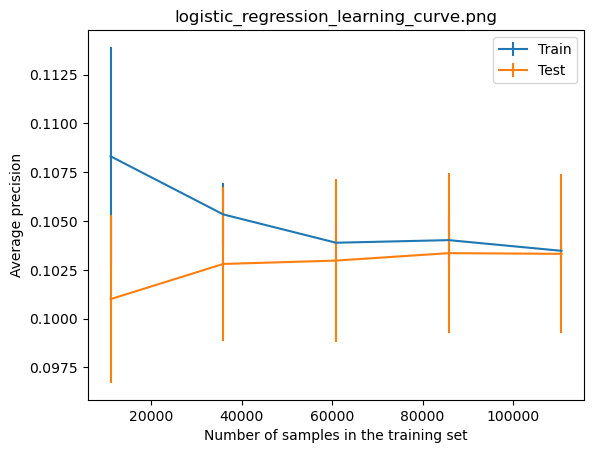

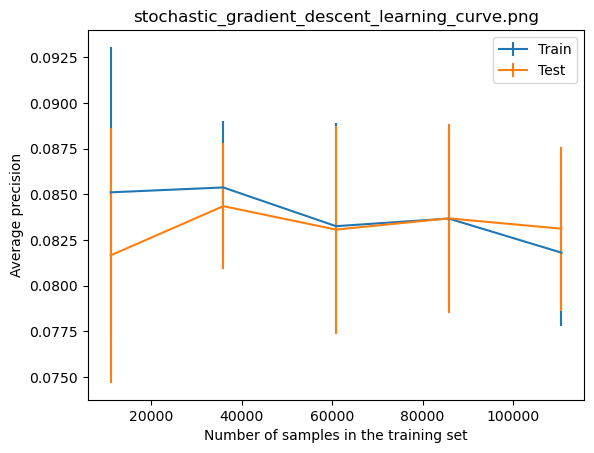

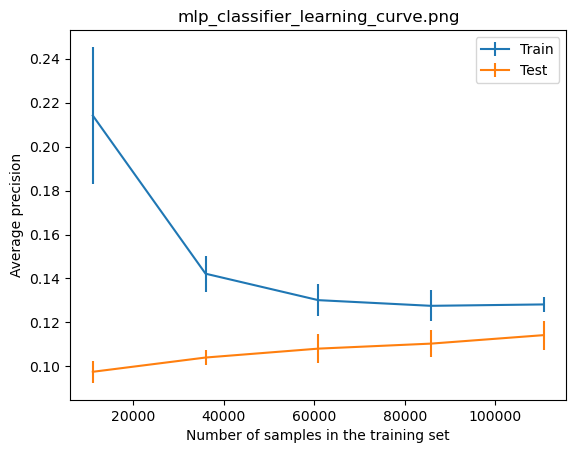

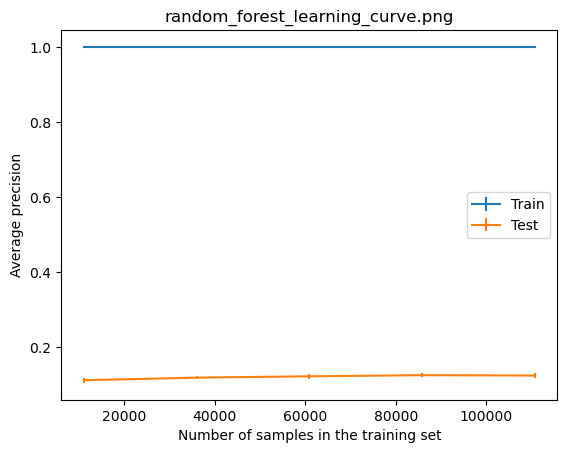

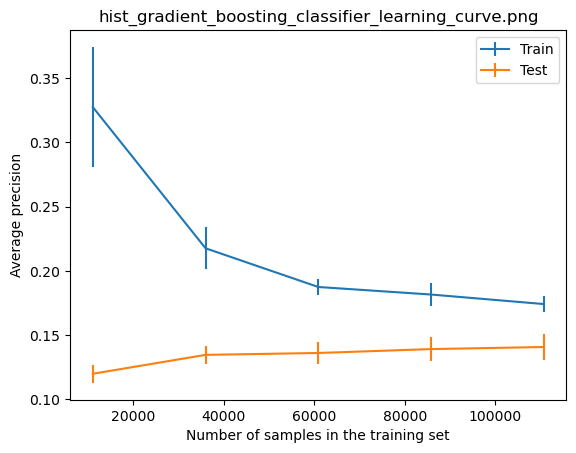

In [19]:
dummy_model = DummyClassifier(strategy='most_frequent', random_state=37)
lr_model =  LogisticRegressionCV(scoring='average_precision', n_jobs=-1, random_state=37)
sgd_model = SGDClassifier(class_weight='balanced', n_jobs=-1, random_state=37)
mlp_model = MLPClassifier(random_state=37)
rdf_model = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=37)
hgb_model = HistGradientBoostingClassifier(class_weight='balanced', random_state=37)

models = [dummy_model, lr_model, sgd_model, mlp_model, rdf_model, hgb_model]
model_names = [
    'dummy_classifier', 'logistic_regression',
    'stochastic_gradient_descent', 'mlp_classifier',
    'random_forest', 'hist_gradient_boosting_classifier'
]
cv = StratifiedKFold(n_splits=10)

learning_curves_dir = model_selection_fig_dir/"learning_curves"
learning_curves_dir.mkdir(parents=True, exist_ok=True)

for model, name in zip(models, model_names):
    LearningCurveDisplay.from_estimator(
        estimator=model,
        X=preprocessed_data, y=target_train,
        cv=cv, scoring='average_precision',
        n_jobs=-1, shuffle=True, random_state=37,
        error_score='raise', std_display_style='errorbar'
    )
    plt.title(f"{name}_learning_curve.png")
    plt.savefig(f"{learning_curves_dir}/{name}.png")
    plt.show()

> dummy_classifier: It is clearly underfitting and adding more data makes no improvement
> 
> logistic_regression: It is clearly underfitting and adding more data makes no improvement
> 
> stochastic_gradient_descent: It is clearly underfitting and adding more data makes no improvement
> 
> mlp_classifier: It shows promises of improvement in the presence of more data
> 
> random_forest: It is clearly overfitting and adding more data makes no improvement
> 
> hist_gradient_boosting_classifier: It shows promises improvment in the presence of more data
>
> Well performing algorithms choosen for hyperparameter tunning are:
1. MLPClassifier
2. HistGradientBoostingClassifier

# Hyperparameter Tuning

In [20]:
outer_cv = StratifiedKFold(n_splits=10)
inner_cv = StratifiedKFold(n_splits=5)

hgb_cv_model = HistGradientBoostingClassifier(class_weight='balanced', random_state=37)

hgb_param_distributions = {
    'learning_rate': np.random.uniform(1e-5, 1.0, 5),
    'max_iter': np.random.randint(10, 500, 10),
    'max_leaf_nodes': np.random.randint(20, 100, 10),
    'max_bins': np.random.randint(50, 255, 10),
    'n_iter_no_change': np.random.randint(5, 15, 5)
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_cv_model,
    param_distributions=hgb_param_distributions,
    scoring='average_precision', cv=inner_cv,
    n_jobs=-1, random_state=37, error_score='raise'
)

hgb_cv_result = cross_validate(
        estimator=hgb_search,
        X=preprocessed_data, y=target_train,
        cv=outer_cv, scoring={"f1": "f1", "pr_auc": "average_precision"},
        n_jobs=-1, error_score="raise", return_estimator=True
)

In [21]:
mlp_cv_model = MLPClassifier(random_state=37)

mlp_param_distributions = {
    'alpha': np.random.uniform(1e-7, 1e-1, 10),
    'max_iter': np.random.randint(100, 700, 10),
    'tol': np.random.uniform(1e-7, 1e-2, 10),
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_cv_model,
    param_distributions=mlp_param_distributions,
    scoring='average_precision', cv=inner_cv,
    n_jobs=-1, random_state=37, error_score='raise'
)

mlp_cv_result = cross_validate(
        estimator=mlp_search,
        X=preprocessed_data, y=target_train,
        cv=outer_cv, scoring={"f1": "f1", "pr_auc": "average_precision"},
        n_jobs=-1, error_score="raise",
)

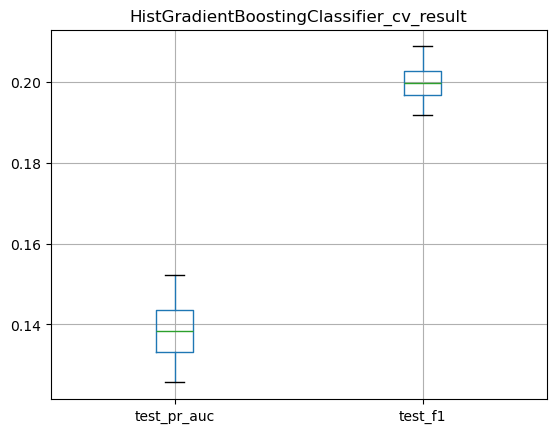

In [22]:
hgb_cv_result_df = pd.DataFrame(hgb_cv_result)
hgb_cv_result_df[['test_pr_auc', 'test_f1']].boxplot()
plt.title('HistGradientBoostingClassifier_cv_result')
plt.show()

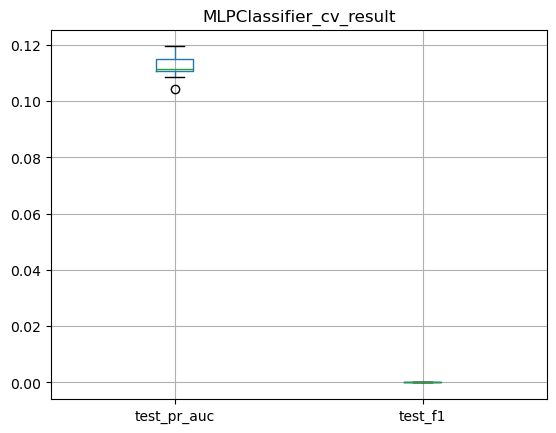

In [23]:
mlp_cv_result = pd.DataFrame(mlp_cv_result)
mlp_cv_result[['test_pr_auc', 'test_f1']].boxplot()
plt.title('MLPClassifier_cv_result')
plt.show()

> The performance of MLPClassifier is roughly same as before even after a randomized search of parameters. But it is significantly more time-costly to train compared to most of the other algorithms.
> 
> HistGradientBoostingClassifier still remains the top performing algorithim in terms of PR-AUC and F1-score

In [24]:
for estimator in hgb_cv_result['estimator']:
    print(estimator.best_params_)

{'n_iter_no_change': np.int32(6), 'max_leaf_nodes': np.int32(39), 'max_iter': np.int32(351), 'max_bins': np.int32(206), 'learning_rate': np.float64(0.19280310100686807)}
{'n_iter_no_change': np.int32(6), 'max_leaf_nodes': np.int32(39), 'max_iter': np.int32(351), 'max_bins': np.int32(206), 'learning_rate': np.float64(0.19280310100686807)}
{'n_iter_no_change': np.int32(6), 'max_leaf_nodes': np.int32(39), 'max_iter': np.int32(351), 'max_bins': np.int32(206), 'learning_rate': np.float64(0.19280310100686807)}
{'n_iter_no_change': np.int32(6), 'max_leaf_nodes': np.int32(39), 'max_iter': np.int32(351), 'max_bins': np.int32(206), 'learning_rate': np.float64(0.19280310100686807)}
{'n_iter_no_change': np.int32(9), 'max_leaf_nodes': np.int32(22), 'max_iter': np.int32(274), 'max_bins': np.int32(139), 'learning_rate': np.float64(0.19280310100686807)}
{'n_iter_no_change': np.int32(9), 'max_leaf_nodes': np.int32(22), 'max_iter': np.int32(274), 'max_bins': np.int32(139), 'learning_rate': np.float64(0.

> BEST PARAMS (Consistent across all ten folds)
>
> n_iter_no_change = 14
> 
> max_leaf_nodes = 20
> 
> max_iter = 323
> 
> max_bins = 139
> 
> learning_rate = 0.023863562745022885


## Selected Algorithm PR-Curve

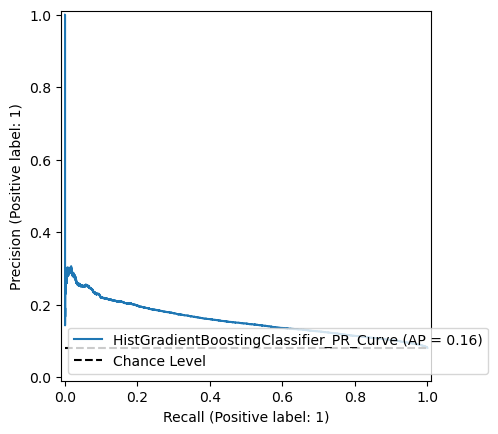

In [25]:
hgb_pr_curve_model = HistGradientBoostingClassifier(
    class_weight='balanced', random_state=37,
    n_iter_no_change = 14, max_leaf_nodes = 20, 
    max_iter = 323, max_bins = 139,
    learning_rate = 0.023863562745022885
)

plot_pr_curve(model=hgb_pr_curve_model, data=preprocessed_data, target=target_train, curve_label='HistGradientBoostingClassifier_PR_Curve')
plt.savefig(f"{model_selection_fig_dir}/selected_algorithm_pr_curve.png")
plt.show()